# Results Analysis and Plots

Loads all experiment CSVs and produces the key figures:
1. Pareto frontier: p_L vs model size across quantization configs
2. Architecture comparison: MWPM vs CNN vs RCNN at full precision
3. Quantization degradation: p_L vs weight bits at fixed (d, p)
4. Distance scaling: p_L vs d for selected quantization configs
5. NaN instability map: which (w, a) configs failed to train

All figures saved to `./plots/`

In [1]:
# Cell 1 — Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
import os

os.makedirs('./plots', exist_ok=True)

In [2]:
# Cell 2 — Load Data

# Load all result CSVs
df_mwpm  = pd.read_csv('./results/results_mwpm.csv')
df_fp    = pd.read_csv('./results/results_fullprecision.csv')
df_quant = pd.read_csv('./results/results_quantization_sweep_qdense.csv')

# Standardize column names across all CSVs
df_mwpm = df_mwpm.rename(columns={
    'distance': 'd',
    'noise':    'p',
    'decoder':  'architecture'
})

df_fp = df_fp.rename(columns={
    'distance': 'd',
    'noise':    'p',
    'decoder':  'architecture'
})

# Standardize decoder names in df_fp to match df_quant style
df_fp['architecture'] = df_fp['architecture'].map({
    'CNN-32bit':  'CNN',
    'RCNN-32bit': 'RCNN'
})

# Mark unstable runs in df_quant (w < 32 and a == 32 = NaN training)
df_quant['stable'] = ~((df_quant['w_bits'] < 32) & (df_quant['a_bits'] == 32))
df_stable   = df_quant[df_quant['stable']].copy()
df_unstable = df_quant[~df_quant['stable']].copy()

# Calculate theoretical model size based on bit-width
# Full precision = 32 bits per parameter
# Quantized = w_bits per parameter for weights (dominant cost)
# Base parameter count from w=32 model at each (d, arch)
param_counts = df_stable[df_stable['w_bits'] == 32].groupby(
    ['architecture', 'd'])['model_size_kb'].first() * 1024 / 4  # bytes→params

def theoretical_size_kb(row):
    key = (row['architecture'], row['d'])
    if key in param_counts.index:
        n_params = param_counts[key]
        return n_params * row['w_bits'] / 8 / 1024
    return row['model_size_kb']

df_stable['theoretical_size_kb'] = df_stable.apply(theoretical_size_kb, axis=1)

print(f'MWPM results:         {len(df_mwpm)} rows')
print(f'Full precision:       {len(df_fp)} rows')
print(f'Quantization total:   {len(df_quant)} rows')
print(f'  Stable:             {len(df_stable)} rows')
print(f'  Unstable (NaN):     {len(df_unstable)} rows')
print(f'\ndf_mwpm columns:  {df_mwpm.columns.tolist()}')
print(f'df_fp columns:    {df_fp.columns.tolist()}')
print(f'df_quant columns: {df_quant.columns.tolist()}')

MWPM results:         12 rows
Full precision:       24 rows
Quantization total:   385 rows
  Stable:             313 rows
  Unstable (NaN):     72 rows

df_mwpm columns:  ['d', 'p', 'architecture', 'p_L', 'n_errors', 'n_samples']
df_fp columns:    ['d', 'p', 'architecture', 'p_L', 'model_size_kb']
df_quant columns: ['architecture', 'w_bits', 'a_bits', 'd', 'p', 'p_L', 'model_size_kb', 'inference_latency_ms', 'stable']


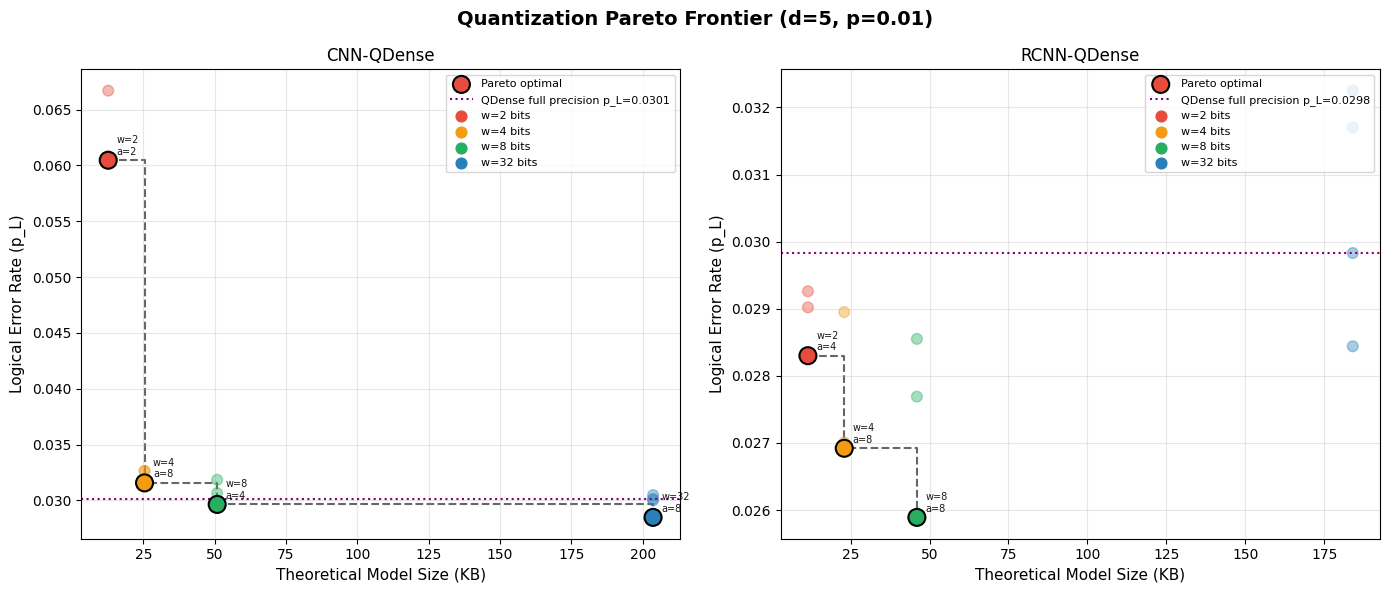

Saved: ./plots/pareto_frontier.png


In [3]:
# Cell 3 — Figure 1: Pareto Frontier at d=5, p=0.01

# The Pareto frontier shows which quantization configs are non-dominated: no other config is both smaller AND more accurate.

ANCHOR_D = 5
ANCHOR_P = 0.010

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'Quantization Pareto Frontier (d={ANCHOR_D}, p={ANCHOR_P})', fontsize=14, fontweight='bold')

for ax, arch in zip(axes, ['CNN-QDense', 'RCNN-QDense']):
    subset = df_stable[
        (df_stable['d'] == ANCHOR_D) &
        (df_stable['p'] == ANCHOR_P) &
        (df_stable['architecture'] == arch)
    ].copy()

    x = subset['theoretical_size_kb'].values
    y = subset['p_L'].values

    # Find Pareto-optimal points (minimize both size and p_L)
    pareto_mask = np.ones(len(subset), dtype=bool)
    for i in range(len(subset)):
        for j in range(len(subset)):
            if i != j and x[j] <= x[i] and y[j] <= y[i]:
                if x[j] < x[i] or y[j] < y[i]:
                    pareto_mask[i] = False
                    break

    # Color points by weight bits
    w_bits_vals = subset['w_bits'].values
    colors_map = {2: '#e74c3c', 4: '#f39c12', 8: '#27ae60', 32: '#2980b9'}
    point_colors = [colors_map[w] for w in w_bits_vals]

    # Plot dominated points
    ax.scatter(x[~pareto_mask], y[~pareto_mask],
               c=[point_colors[i] for i in np.where(~pareto_mask)[0]],
               s=60, alpha=0.4, zorder=2)

    # Plot Pareto-optimal points
    ax.scatter(x[pareto_mask], y[pareto_mask],
               c=[point_colors[i] for i in np.where(pareto_mask)[0]],
               s=150, alpha=1.0, edgecolors='black', linewidth=1.5,
               zorder=3, label='Pareto optimal')

    # Draw Pareto frontier line
    pareto_pts = sorted(zip(x[pareto_mask], y[pareto_mask]))
    if pareto_pts:
        px, py = zip(*pareto_pts)
        ax.step(px, py, where='post', color='black', linewidth=1.5,
                linestyle='--', alpha=0.6, zorder=1)

    # Annotate Pareto points with (w, a)
    for i in np.where(pareto_mask)[0]:
        w = int(subset.iloc[i]['w_bits'])
        a = int(subset.iloc[i]['a_bits'])
        ax.annotate(f'w={w}\na={a}',
                    (x[i], y[i]),
                    xytext=(6, 4), textcoords='offset points',
                    fontsize=7, alpha=0.9)

    # Full precision reference line
    fp_val = df_stable[(df_stable['architecture'] == arch) &
                   (df_stable['d'] == ANCHOR_D) &
                   (df_stable['p'] == ANCHOR_P) &
                   (df_stable['w_bits'] == 32) &
                   (df_stable['a_bits'] == 32)]['p_L'].values
    if len(fp_val) > 0:
        ax.axhline(fp_val[0], color='purple', linestyle=':', linewidth=1.5,
               label=f'QDense full precision p_L={fp_val[0]:.4f}')

    # Legend for weight bits
    for w, c in colors_map.items():
        ax.scatter([], [], color=c, s=60, label=f'w={w} bits')

    ax.set_xlabel('Theoretical Model Size (KB)', fontsize=11)
    ax.set_ylabel('Logical Error Rate (p_L)', fontsize=11)
    ax.set_title(arch, fontsize=12)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/pareto_frontier.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./plots/pareto_frontier.png')

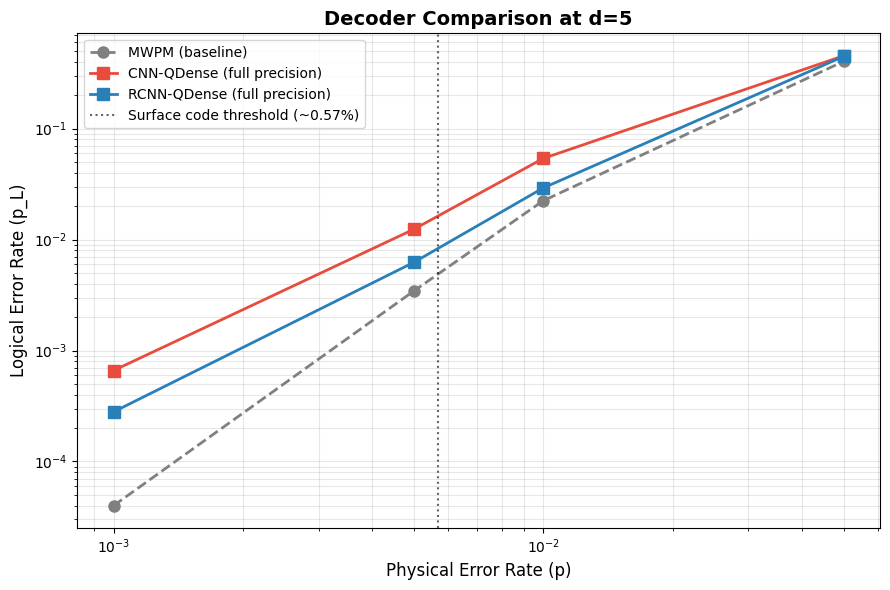

Saved: ./plots/architecture_comparison.png


In [4]:
# Cell 4 — Figure 2: Architecture Comparison (MWPM vs Full Precision)

# Shows how CNN-QDense and RCNN-QDense compare to MWPM baseline across all physical error rates at d=5.

D_VAL = 5
P_VALS = [0.001, 0.005, 0.010, 0.050]

fig, ax = plt.subplots(figsize=(9, 6))

# MWPM baseline
mwpm_sub = df_mwpm[df_mwpm['d'] == D_VAL].sort_values('p')
ax.loglog(mwpm_sub['p'], mwpm_sub['p_L'],
          'o--', color='gray', linewidth=2, markersize=8, label='MWPM (baseline)')

# Full precision CNN and RCNN
colors = {'CNN': '#e74c3c', 'RCNN': '#2980b9'}
for arch in ['CNN', 'RCNN']:
    fp_sub = df_fp[(df_fp['architecture'] == arch) &
                   (df_fp['d'] == D_VAL)].sort_values('p')
    ax.loglog(fp_sub['p'], fp_sub['p_L'],
              's-', color=colors[arch], linewidth=2, markersize=8,
              label=f'{arch}-QDense (full precision)')

# Surface code threshold reference
ax.axvline(0.0057, color='black', linestyle=':', linewidth=1.5, alpha=0.6,
           label='Surface code threshold (~0.57%)')

ax.set_xlabel('Physical Error Rate (p)', fontsize=12)
ax.set_ylabel('Logical Error Rate (p_L)', fontsize=12)
ax.set_title(f'Decoder Comparison at d={D_VAL}', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('./plots/architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./plots/architecture_comparison.png')

In [5]:
print(df_fp[['d', 'p', 'architecture']].to_string())

    d      p architecture
0   3  0.001          CNN
1   3  0.001         RCNN
2   3  0.005          CNN
3   3  0.005         RCNN
4   3  0.010          CNN
5   3  0.010         RCNN
6   3  0.050          CNN
7   3  0.050         RCNN
8   5  0.001          CNN
9   5  0.001         RCNN
10  5  0.005          CNN
11  5  0.005         RCNN
12  5  0.010          CNN
13  5  0.010         RCNN
14  5  0.050          CNN
15  5  0.050         RCNN
16  7  0.001          CNN
17  7  0.001         RCNN
18  7  0.005          CNN
19  7  0.005         RCNN
20  7  0.010          CNN
21  7  0.010         RCNN
22  7  0.050          CNN
23  7  0.050         RCNN


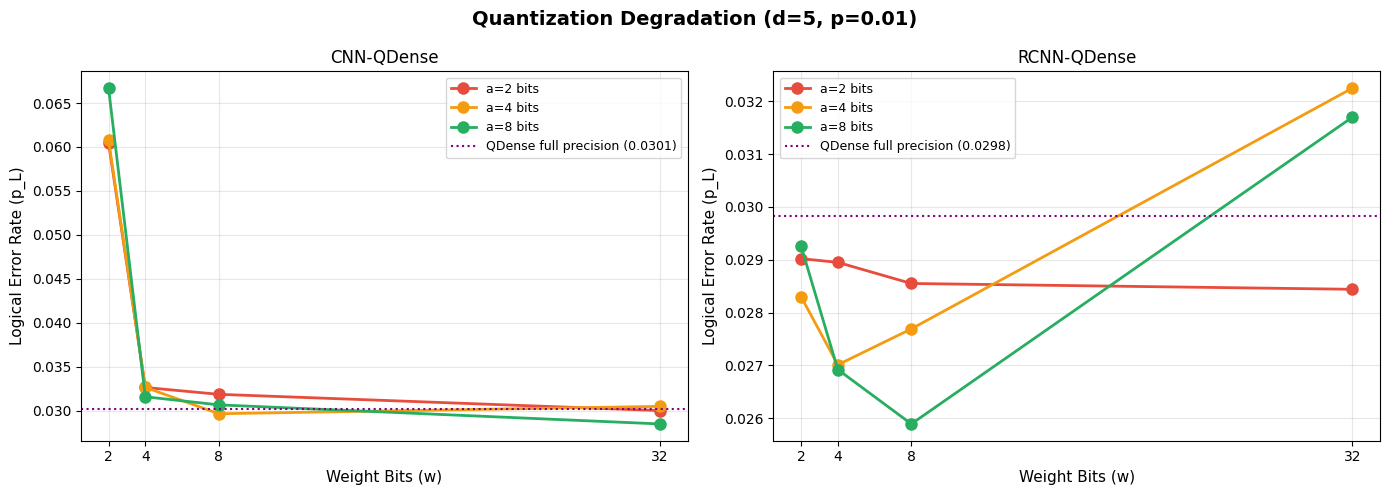

Saved: ./plots/quantization_degradation.png


In [11]:
# Cell 5 — Figure 3: Quantization Degradation at d=5, p=0.01

# Shows how p_L changes as weight bits decrease, for each activation bit-width. Reveals whether weight bits >> activation bits

ANCHOR_D = 5
ANCHOR_P = 0.010
A_BITS_VALS = [2, 4, 8]  # exclude 32 (unstable for w<32)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Quantization Degradation (d={ANCHOR_D}, p={ANCHOR_P})',
             fontsize=14, fontweight='bold')

colors_a = {2: '#e74c3c', 4: '#f39c12', 8: '#27ae60'}
w_order  = [2, 4, 8, 32]

for ax, arch in zip(axes, ['CNN-QDense', 'RCNN-QDense']):
    subset = df_stable[
        (df_stable['d'] == ANCHOR_D) &
        (df_stable['p'] == ANCHOR_P) &
        (df_stable['architecture'] == arch)
    ]

    for a_bits in A_BITS_VALS:
        line_data = subset[subset['a_bits'] == a_bits].sort_values('w_bits')
        ax.plot(line_data['w_bits'], line_data['p_L'],
                'o-', color=colors_a[a_bits], linewidth=2, markersize=8,
                label=f'a={a_bits} bits')

    # Full precision reference
    fp_val = df_stable[(df_stable['architecture'] == arch) &
                   (df_stable['d'] == ANCHOR_D) &
                   (df_stable['p'] == ANCHOR_P) &
                   (df_stable['w_bits'] == 32) &
                   (df_stable['a_bits'] == 32)]['p_L'].values
    if len(fp_val) > 0:
        ax.axhline(fp_val[0], color='purple', linestyle=':', linewidth=1.5,
                label=f'QDense full precision ({fp_val[0]:.4f})')

    ax.set_xlabel('Weight Bits (w)', fontsize=11)
    ax.set_ylabel('Logical Error Rate (p_L)', fontsize=11)
    ax.set_title(arch, fontsize=12)
    ax.set_xticks(w_order)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./plots/quantization_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./plots/quantization_degradation.png')

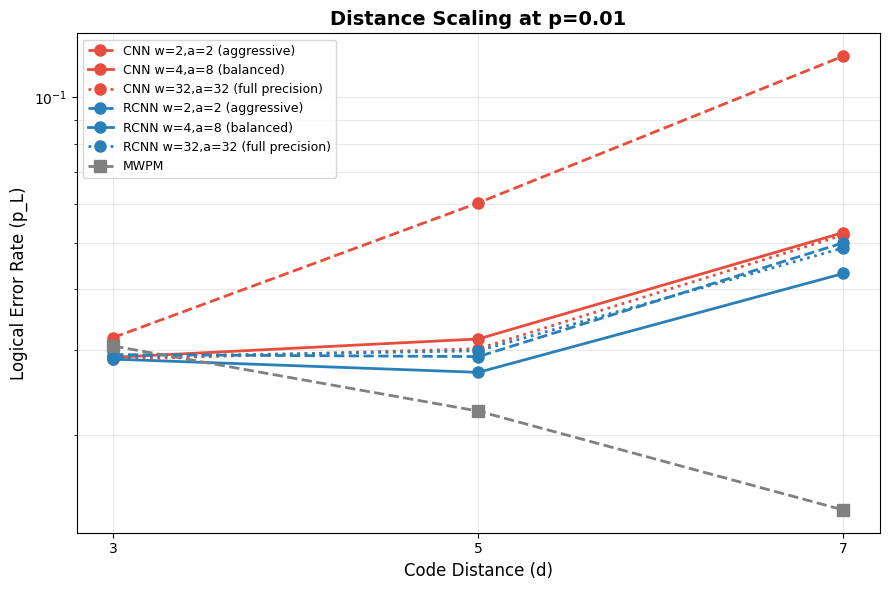

Saved: ./plots/distance_scaling.png


In [7]:
# Cell 6 — Figure 4: Distance Scaling
# Shows p_L vs code distance d for selected quantization configs at fixed p=0.01. Reveals whether quantization degrades more at larger distances.

ANCHOR_P    = 0.010
D_VALS      = [3, 5, 7]

# Select representative configs to plot
configs_to_plot = [
    ('CNN-QDense',  2,  2, '#e74c3c', '--', 'CNN w=2,a=2 (aggressive)'),
    ('CNN-QDense',  4,  8, '#e74c3c', '-',  'CNN w=4,a=8 (balanced)'),
    ('CNN-QDense', 32, 32, '#e74c3c', ':',  'CNN w=32,a=32 (full precision)'),
    ('RCNN-QDense', 2,  2, '#2980b9', '--', 'RCNN w=2,a=2 (aggressive)'),
    ('RCNN-QDense', 4,  8, '#2980b9', '-',  'RCNN w=4,a=8 (balanced)'),
    ('RCNN-QDense',32, 32, '#2980b9', ':',  'RCNN w=32,a=32 (full precision)'),
]

fig, ax = plt.subplots(figsize=(9, 6))

for arch, w, a, color, ls, label in configs_to_plot:
    pts = []
    for d in D_VALS:
        row = df_stable[
            (df_stable['architecture'] == arch) &
            (df_stable['w_bits'] == w) &
            (df_stable['a_bits'] == a) &
            (df_stable['d'] == d) &
            (df_stable['p'] == ANCHOR_P)
        ]
        if len(row) > 0:
            pts.append((d, row['p_L'].values[0]))
    if pts:
        dx, dy = zip(*pts)
        ax.semilogy(dx, dy, 'o'+ls, color=color, linewidth=2,
                    markersize=8, label=label)

# MWPM reference
mwpm_sub = df_mwpm[df_mwpm['p'] == ANCHOR_P].sort_values('d')
ax.semilogy(mwpm_sub['d'], mwpm_sub['p_L'],
            's--', color='gray', linewidth=2, markersize=8, label='MWPM')

ax.set_xlabel('Code Distance (d)', fontsize=12)
ax.set_ylabel('Logical Error Rate (p_L)', fontsize=12)
ax.set_title(f'Distance Scaling at p={ANCHOR_P}', fontsize=14, fontweight='bold')
ax.set_xticks(D_VALS)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('./plots/distance_scaling.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./plots/distance_scaling.png')

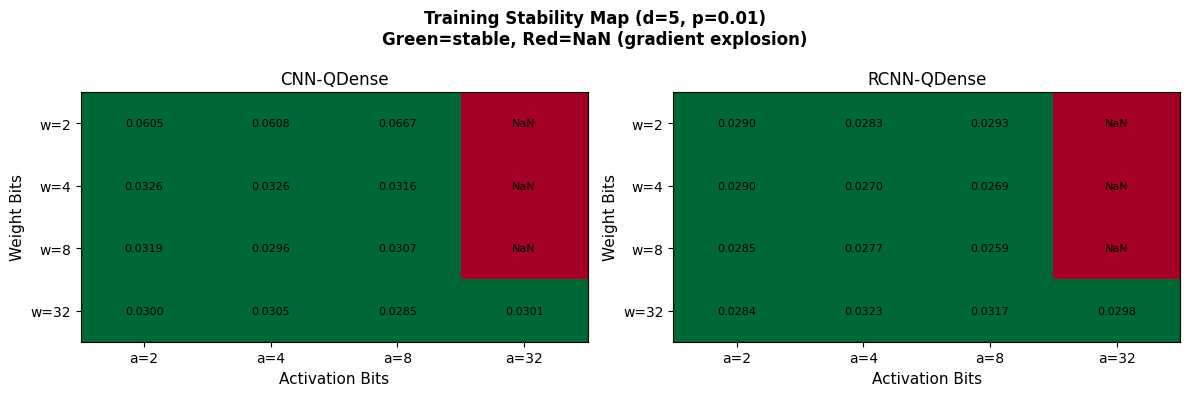

Saved: ./plots/stability_heatmap.png


In [8]:
# Cell 7 — Figure 5: NaN Instability Heatmap

# Shows which (w, a) configurations failed to train (NaN loss) at d=5, p=0.01. This shows QAT stability.

ANCHOR_D = 5
ANCHOR_P = 0.010
W_VALS   = [2, 4, 8, 32]
A_VALS   = [2, 4, 8, 32]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f'Training Stability Map (d={ANCHOR_D}, p={ANCHOR_P})\n'
             f'Green=stable, Red=NaN (gradient explosion)',
             fontsize=12, fontweight='bold')

for ax, arch in zip(axes, ['CNN-QDense', 'RCNN-QDense']):
    subset = df_quant[
        (df_quant['d'] == ANCHOR_D) &
        (df_quant['p'] == ANCHOR_P) &
        (df_quant['architecture'] == arch)
    ]

    # Build stability matrix
    matrix = np.zeros((len(W_VALS), len(A_VALS)))
    for i, w in enumerate(W_VALS):
        for j, a in enumerate(A_VALS):
            row = subset[(subset['w_bits'] == w) & (subset['a_bits'] == a)]
            if len(row) > 0:
                matrix[i, j] = 1.0 if row['stable'].values[0] else 0.0

    im = ax.imshow(matrix, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    # Annotate cells with p_L
    for i, w in enumerate(W_VALS):
        for j, a in enumerate(A_VALS):
            row = subset[(subset['w_bits'] == w) & (subset['a_bits'] == a)]
            if len(row) > 0:
                val = row['p_L'].values[0]
                text = f'{val:.4f}' if row['stable'].values[0] else 'NaN'
                ax.text(j, i, text, ha='center', va='center', fontsize=8,
                        color='black')

    ax.set_xticks(range(len(A_VALS)))
    ax.set_yticks(range(len(W_VALS)))
    ax.set_xticklabels([f'a={a}' for a in A_VALS])
    ax.set_yticklabels([f'w={w}' for w in W_VALS])
    ax.set_xlabel('Activation Bits', fontsize=11)
    ax.set_ylabel('Weight Bits', fontsize=11)
    ax.set_title(arch, fontsize=12)

plt.tight_layout()
plt.savefig('./plots/stability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ./plots/stability_heatmap.png')

In [13]:
# Cell 8 — Summary Statistics Table
ANCHOR_D = 5
ANCHOR_P = 0.010

print(f'\n=== Summary Table: d={ANCHOR_D}, p={ANCHOR_P} ===')
print(f'{"Decoder":<30} {"w":>4} {"a":>4} {"p_L":>10} {"Size(KB)":>10} {"Latency(ms)":>12}')
print('-' * 75)

# MWPM
mwpm_row = df_mwpm[(df_mwpm['d'] == ANCHOR_D) & (df_mwpm['p'] == ANCHOR_P)]
if len(mwpm_row) > 0:
    print(f'{"MWPM (PyMatching)":<30} {"—":>4} {"—":>4} '
          f'{mwpm_row["p_L"].values[0]:>10.6f} {"—":>10} {"—":>12}')

print('-' * 75)

# Full precision and best quantized per architecture
for arch in ['CNN-QDense', 'RCNN-QDense']:
    # Full precision (w=32, a=32)
    fp_row = df_stable[
        (df_stable['architecture'] == arch) &
        (df_stable['d'] == ANCHOR_D) &
        (df_stable['p'] == ANCHOR_P) &
        (df_stable['w_bits'] == 32) &
        (df_stable['a_bits'] == 32)
    ]
    if len(fp_row) > 0:
        r = fp_row.iloc[0]
        print(f'{arch + " (full precision)":<30} '
              f'{32:>4} {32:>4} {r["p_L"]:>10.6f} '
              f'{r["model_size_kb"]:>10.1f} {r["inference_latency_ms"]:>12.1f}')

    # Best quantized config (exclude w=32 a=32)
    subset = df_stable[
        (df_stable['architecture'] == arch) &
        (df_stable['d'] == ANCHOR_D) &
        (df_stable['p'] == ANCHOR_P) &
        ~((df_stable['w_bits'] == 32) & (df_stable['a_bits'] == 32))
    ]
    best = subset.loc[subset['p_L'].idxmin()]
    print(f'{arch + " (best quantized)":<30} '
          f'{int(best["w_bits"]):>4} {int(best["a_bits"]):>4} '
          f'{best["p_L"]:>10.6f} '
          f'{best["model_size_kb"]:>10.1f} {best["inference_latency_ms"]:>12.1f}')

print('-' * 75)
print('\nNote: .h5 file size overstates quantized model size due to QKeras metadata.')
print('Theoretical size reduction = 32/w_bits (e.g. w=8 → 4× smaller than w=32).')


=== Summary Table: d=5, p=0.01 ===
Decoder                           w    a        p_L   Size(KB)  Latency(ms)
---------------------------------------------------------------------------
MWPM (PyMatching)                 —    —   0.022370          —            —
---------------------------------------------------------------------------
CNN-QDense (full precision)      32   32   0.030140      203.6         66.5
CNN-QDense (best quantized)      32    8   0.028480      203.6         26.3
RCNN-QDense (full precision)     32   32   0.029830      184.0         65.8
RCNN-QDense (best quantized)      8    8   0.025890      189.0         28.5
---------------------------------------------------------------------------

Note: .h5 file size overstates quantized model size due to QKeras metadata.
Theoretical size reduction = 32/w_bits (e.g. w=8 → 4× smaller than w=32).
